### Packages

In [40]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import random

In [41]:
GLOBAL_SEED = 88888888
np.random.seed(GLOBAL_SEED)

### Environment

In [42]:
# number of participants
n = 50 

# number of arms/actions
arms = 2

# reward noise
sigma_r = 1

# reward generator
def get_reward(rng_local, i, a):
    return rng_local.normal(loc=theta[i, a], scale=sigma_r)

In [43]:
def set_environment(n_new, arms_new, mu_vec, tau_vec, env_seed=0):
    global n, arms, theta, rng

    n = int(n_new)
    arms = int(arms_new)

    rng = np.random.default_rng(env_seed)

    mu_vec = np.asarray(mu_vec, dtype=float)
    tau_vec = np.asarray(tau_vec, dtype=float)
    
    if mu_vec.ndim == 0:
        mu_vec = np.full(arms, float(mu_vec))
    if tau_vec.ndim == 0:
        tau_vec = np.full(arms, float(tau_vec))

    theta = np.zeros((n, arms))

    for a in range(arms):
        theta[:, a] = rng.normal(
            loc=mu_vec[a],
            scale=tau_vec[a],
            size=n
        )

#### Simulation specifics

In [44]:
# number of decision times
T = 200

# rate
epsilon = 0

# estimate of arm value
Q = np.zeros((n, arms))

# number of times arm tried
N = np.zeros((n, arms), dtype=int)

actions = np.zeros((n, T), dtype=int)
rewards = np.zeros((n, T))

### Empirical Bayes

In [45]:
def learning_empirical_bayes(times, participants, n_arms, mu0, tau0, seed=0):
    rng = np.random.default_rng(seed)
    sigma2 = float(sigma_r) ** 2
    
    if np.isscalar(mu0):
        mu0_vec = np.full(n_arms, float(mu0))
    else:
        mu0_vec = np.asarray(mu0, dtype=float)
    
    if np.isscalar(tau0):
        tau0_vec = np.full(n_arms, float(tau0))
    else:
        tau0_vec = np.asarray(tau0, dtype=float)
    
    m = np.tile(mu0_vec, (participants, 1))
    v = np.tile(tau0_vec**2, (participants, 1))

    N = np.zeros((participants, n_arms), dtype=int)
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    def normal_cdf(z):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

    # the two functions below fit the hierarchical model based on learning algorithm's outputs 
    def profile_ll_and_mu(x, s2, tau2):
        w = 1.0 / (s2 + tau2)
        mu = np.sum(w * x) / np.sum(w)
        ll = -0.5 * np.sum(np.log(s2 + tau2) + (x - mu) ** 2 * w)
        return ll, mu

    def fit_mu_tau2(x, s2):
        x = np.asarray(x, dtype=float)
        s2 = np.asarray(s2, dtype=float)

        base = float(np.var(x)) + float(np.mean(s2))
        hi = max(1e-6, 10.0 * base)
        grid = np.logspace(-8, np.log10(hi), 120)

        best_tau2 = 0.0
        best_ll, best_mu = profile_ll_and_mu(x, s2, 0.0)

        for tau2 in grid:
            ll, mu = profile_ll_and_mu(x, s2, float(tau2))
            if ll > best_ll:
                best_ll, best_mu, best_tau2 = ll, mu, float(tau2)

        return best_mu, best_tau2

    # okay let's loop through all the decision times using the functions we defined above to do EB
    for t in range(times):
        # these are the *hyper*parameters aka population-level parameters
        mu_hat = np.zeros(n_arms, dtype=float)
        tau2_hat = np.zeros(n_arms, dtype=float)

        for a in range(n_arms):
            mu_hat[a], tau2_hat[a] = fit_mu_tau2(m[:, a], v[:, a])

        # these are the *person*-level parameters
        m_eb = np.zeros_like(m, dtype=float)
        v_eb = np.zeros_like(v, dtype=float)

        # let's compute the posteriors .....
        for a in range(n_arms):
            if tau2_hat[a] <= 0.0:
                m_eb[:, a] = mu_hat[a]
                v_eb[:, a] = 0.0
            else:
                lam = tau2_hat[a] / (tau2_hat[a] + v[:, a])
                m_eb[:, a] = lam * m[:, a] + (1.0 - lam) * mu_hat[a]
                v_eb[:, a] = 1.0 / (1.0 / v[:, a] + 1.0 / tau2_hat[a])

        # now using the posteriors we can determine distribution of difference between the two arms & based on that we select an action!
        for i in range(participants):
            if n_arms == 2:
                m_diff = m_eb[i, 1] - m_eb[i, 0]
                v_diff = v_eb[i, 1] + v_eb[i, 0]
                if v_diff <= 0.0:
                    a = 1 if m_diff > 0.0 else 0
                else:
                    p1 = normal_cdf(m_diff / math.sqrt(v_diff))
                    a = 1 if rng.random() < p1 else 0
            else:
                sample = rng.normal(loc=m_eb[i], scale=np.sqrt(np.maximum(v_eb[i], 0.0)))
                a = int(np.argmax(sample))

            # reward time! yay! let's see what reward we get based on the action...
            r = get_reward(rng, i, a)

            actions[i, t] = a
            rewards[i, t] = r
            N[i, a] += 1

            # okay time to learn from the reward
            prec = 1.0 / v[i, a] + 1.0 / sigma2
            v_new = 1.0 / prec
            m_new = v_new * (m[i, a] / v[i, a] + r / sigma2)

            m[i, a] = m_new
            v[i, a] = v_new

    return m, v, N, actions, rewards

#### Cumulative Regret

Case where algorithm prior is magically true mean.

In [46]:
def cumulative_regret(theta, actions):
    n, T = actions.shape
    best = theta.max(axis=1, keepdims=True)
    chosen = theta[np.arange(n)[:, None], actions]
    inst = best - chosen
    return np.cumsum(inst.mean(axis=0))

def evaluate(seed=8888888, eps=None, mu0=0.0, tau0=1.0):
    if eps is None:
        eps = epsilon

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, mu0=mu0, tau0=tau0, seed=seed
    )

    reg_eb = cumulative_regret(theta, actions_eb)

    return {
        "actions_eb": actions_eb,
        "regret_eb": reg_eb,
        "rewards_eb": rewards_eb,
        "m_eb": m_eb,
        "v_eb": v_eb,
        "N_eb": N_eb,
    }

In [53]:
def plot(ns, mus, taus, prior_list, n_runs, env_seed=0, eps=None):
    if eps is None:
        eps = epsilon

    PASTEL = {"eb": "#8DE5A1"}

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                set_environment(n_val, arms, mu_val, tau_val, env_seed=env_seed)

                ax = axs[i, j]

                for prior in prior_list:
                    reg_eb_list = []
                
                    for r in range(n_runs):
                        # Handle the "Correct Prior" case - use current environment params
                        if prior["label"] == "Correct Prior":
                            prior_mu = mu_val
                            prior_tau = tau_val
                        else:
                            prior_mu = prior["mu0"]
                            prior_tau = prior["tau0"]
                        
                        # Debug print to verify values
                        print(f"Plot: mu_val={mu_val}, prior_mu={prior_mu}, tau_val={tau_val}, prior_tau={prior_tau}")
                        
                        out = evaluate(
                            seed=r,
                            eps=eps,
                            mu0=prior_mu,
                            tau0=prior_tau
                        )
                        reg_eb_list.append(out["regret_eb"])
                
                    reg_eb = np.mean(reg_eb_list, axis=0)
                
                    ax.plot(
                        reg_eb,
                        linewidth=1.4,
                        label=prior["label"]
                    )

                ax.set_title(f"μ={mu_val}, τ={tau_val}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        # legend
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=8)

        fig.suptitle(f"n = {n_val}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()

Below, we show that regret is invariant to translation of the mean. 

Plot: mu_val=[-30, -30], prior_mu=[-30, -30], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[-30, -30], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[-30, -30], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[-30, -30], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[-30, -30], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[0, 0], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[0, 0], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[0, 0], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[0, 0], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[-30, -30], prior_mu=[0, 0], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[14, 14], prior_mu=[14, 14], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[14, 14], prior_mu=[14, 14], tau_val=[1, 1], prior_tau=[1, 1]
Plot: mu_val=[14, 14], prior_mu=[14, 14], tau_val=[1, 1], prior_tau=[1, 1]
Plot:

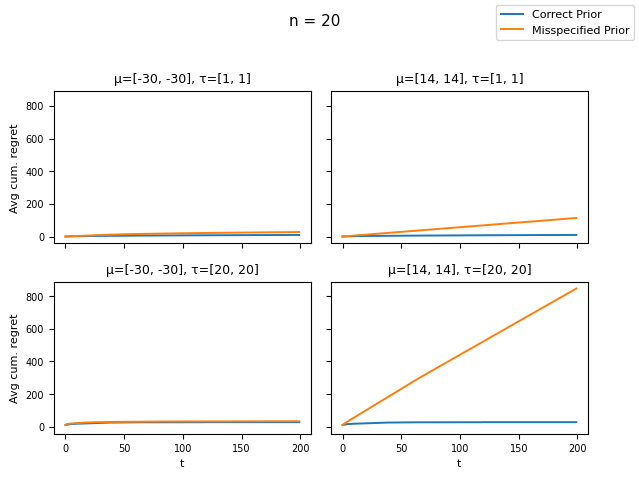

In [54]:
n_runs = 5

ns = [20]

mu_pairs = [
    [-30, -30],
    [14, 14]
]

tau_pairs = [
    [1, 1],
    [20, 20]
]

prior_list = [
    {"mu0": "use_env", "tau0": "use_env", "label": "Correct Prior"},  # Flag to use env params
    {"mu0": [0, 0], "tau0": [1, 1], "label": "Misspecified Prior"}
]

plot(ns, mu_pairs, tau_pairs, prior_list, n_runs)

In [41]:
def learning(times, participants, eps, n_arms, seed=0):
    # rng = np.random.default_rng(seed)
    r = rng.normal(loc=theta, scale=sigma_r)
    
    # estimate of arm value
    Q_new = np.zeros((participants, n_arms)) # will explore if reward is negative
    #Q_new = np.full((participants, n_arms), -100000)
    # Q_new[:, 0] = 0.0

    # number of times arm tried
    N_new = np.zeros((participants, n_arms), dtype=int)

    actions_new = np.zeros((participants, times), dtype=int)
    rewards_new = np.zeros((participants, times))

    
    for t in range(times):
        for i in range(participants):
            # choose action

            untried = np.flatnonzero(N_new[i] == 0)
            if untried.size > 0:
                a = int(untried[0])
            else:
                if rng.random() < eps: 
                    # exploring something new
                    a = rng.integers(0, n_arms)
                else: 
                    # do what we think is best
                    a = int(np.argmax(Q_new[i]))

            # print("WHAT")
            
            r = get_reward(i, a)

            actions_new[i, t] = a
            rewards_new[i, t] = r

            N_new[i, a] += 1
            Q_new[i, a] += (r - Q_new[i, a]) / N_new[i, a]

    return Q_new, N_new, actions_new, rewards_new

Q, N, actions, rewards = learning(T, n, epsilon, arms)

In [ ]:
def thompson_sampling(times, participants, n_arms, theta, sigma_r, mu0 = 0, tau0 = 1, seed = 0):
    rng = np.random.default_rng(seed)

    # number of times person i tried arm a
    N = np.zeros((participants, n_arms), dtype=int)

    # sum of rewards for specific arm
    S = np.zeros((participants, n_arms), dtype=float)
    
    #actions = np.zeros((participants, times), dtype=int)
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    for t in range(times):
        for i in range(participants):
            # posterior information per arm and person
            
            post_mean = np.zeros(n_arms, dtype=float)
            post_var  = np.ones(n_arms, dtype=float)

            for a in range(n_arms):
                if N[i, a] == 0: # 0 arms checked
                    # No data yet . posterior = prior
                    post_mean[a] = mu0
                    post_var[a]  = tau0**2
                else:
                    # have data so do normal-normal conjugacy to update
                    precision_data  = N[i, a] / (sigma_r**2)
                    precision_prior = 1.0 / (tau0**2)

                    post_var[a]  = 1.0 / (precision_data + precision_prior)
                    post_mean[a] = post_var[a] * (mu0/(tau0**2) + S[i,a]/(sigma_r**2))

            sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))

            # choose arm that is best 
            a_star = int(np.argmax(sampled))

            r = get_reward_ts(theta, i, a_star, sigma_r, rng)

            actions[i, t] = a_star
            rewards[i, t] = r

            N[i, a_star] += 1
            S[i, a_star] += r

    return N, S, actions, rewards
            

In [ ]:
def cumulative_regret(theta, actions):
    n, T = actions.shape
    best = theta.max(axis=1, keepdims=True)
    chosen = theta[np.arange(n)[:, None], actions]
    inst = best - chosen
    return np.cumsum(inst.mean(axis=0))

def evaluate(seed=8888888, eps=None, mu0=0.0, tau0=1.0):
    if eps is None:
        eps = epsilon

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, mu0=mu0, tau0=tau0, seed=seed
    )

    reg_eb = cumulative_regret(theta, actions_eb)

    return {
        "actions_eb": actions_eb,
        "regret_eb": reg_eb,
        "rewards_eb": rewards_eb,
        "m_eb": m_eb,
        "v_eb": v_eb,
        "N_eb": N_eb,
    }

In [ ]:
def plot(ns, mus, taus, n_runs=10, env_seed=0, eps=None):
    if eps is None:
        eps = epsilon

    PASTEL = {"eb": "#8DE5A1"}

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                set_environment(n_val, arms, mu_val, tau_val, env_seed=env_seed)

                reg_eb_list = []
                for r in range(n_runs):
                    out = evaluate(seed=r, eps=eps, mu0=mu_val, tau0=tau_val)
                    reg_eb_list.append(out["regret_eb"])

                reg_eb = np.mean(reg_eb_list, axis=0)

                ax = axs[i, j]
                ax.plot(reg_eb, color=PASTEL["eb"], linewidth=1.4, label="EB")

                ax.set_title(f"μ={mu_val}, τ={tau_val}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        # legend (just EB)
        handles, labels = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=8)

        fig.suptitle(f"n = {n_val}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()